Imports

In [9]:
import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt
import pysentiment2 as ps
import torch
import shap

from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, ConfusionMatrixDisplay
from transformers import AutoTokenizer, AutoModelForSequenceClassification


# Load the dataset
import ast
import json

def parse_decisions(s):
    if not isinstance(s, str):
        return None
    try:
        return ast.literal_eval(s)
    except Exception:
        try:
            # fallback: replace single quotes with double quotes carefully
            return json.loads(s.replace("'", '"'))
        except Exception:
            return None

df_raw = pd.read_csv("SEntFiN.csv")
df_raw["_parsed"] = df_raw["Decisions"].apply(parse_decisions)
df_raw = df_raw[df_raw["_parsed"].notna()]
df_raw = df_raw[df_raw["_parsed"].apply(len) == 1].copy()
df_raw["label"] = df_raw["_parsed"].apply(lambda d: list(d.values())[0]).str.strip().str.lower()
df = df_raw.rename(columns={"Title": "sentence"})[["sentence", "label"]].reset_index(drop=True)

print(f"Loaded {len(df)} sentences")
print(df["label"].value_counts())


Loaded 7906 sentences
label
positive    2837
neutral     2693
negative    2376
Name: count, dtype: int64


### STAGE 1: Lightweight cascade classifier


Train 5691  Val 633  Test 1582
Feature dim 1006

Validation threshold sweep
    threshold  coverage  accuracy
0        0.40  0.969984  0.778502
1        0.45  0.902054  0.798599
2        0.50  0.813586  0.831068
3        0.55  0.721959  0.864333
4        0.60  0.630332  0.897243
5        0.65  0.549763  0.905172
6        0.70  0.489731  0.919355
7        0.75  0.409163  0.945946
8        0.80  0.322275  0.975490
9        0.85  0.235387  1.000000
10       0.90  0.172196  1.000000
11       0.95  0.060032  1.000000
12       0.99  0.001580  1.000000

Auto-selected threshold on val: 0.8 (hits 95% at 32.2% val coverage)

Results for Stage 1 on test with threshold 0.8
Sentence Coverage 33.8%  (534 / 1582)
Accuracy on classified 0.964
Not classified in stage 1, goes to stage 2 1048


/var/folders/jf/x1r87km54r5cn89f9b36r79r0000gn/T/ipykernel_11094/3945365115.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


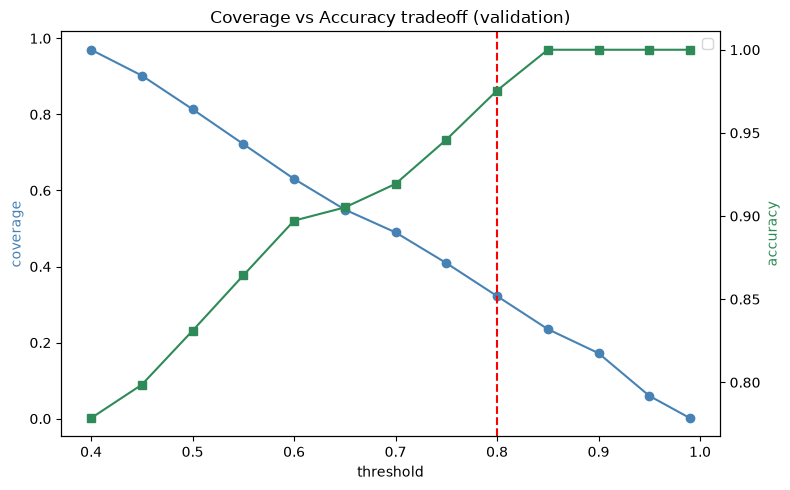

In [10]:
#Load Loughran-McDonald dictionary
lm = ps.LM()

#Feature engineering
def extract_lm_features(sentence):
    tokens = lm.tokenize(sentence)
    scores = lm.get_score(tokens)
    n_words = len(tokens)
    n_numbers = len(re.findall(r'\d+\.?\d*', sentence))
    return [
        scores["Positive"],
        scores["Negative"],
        scores["Polarity"],
        scores["Subjectivity"],
        n_words,
        n_numbers,
    ]

# Extract LM features by looping thru sentences
lm_features = np.array([extract_lm_features(s) for s in df["sentence"]])
y = df["label"].astype(str).to_numpy()
sentences = df["sentence"].tolist()

# 80/20 for test, then 90/10 of the rest for train/val
idx = np.arange(len(df))
idx_temp, idx_test = train_test_split(idx, test_size=0.20, stratify=y, random_state=42)
idx_train, idx_val = train_test_split(idx_temp, test_size=0.10, stratify=y[idx_temp], random_state=42)

sent_train = [sentences[i] for i in idx_train]
sent_val   = [sentences[i] for i in idx_val]
sent_test  = [sentences[i] for i in idx_test]
y_train = y[idx_train]
y_val   = y[idx_val]
y_test  = y[idx_test]


# Fit TF-IDF on training sentences only, then transform val and test
tfidf = TfidfVectorizer(
    max_features=1000,
    min_df=2,
    ngram_range=(1, 1),
    stop_words="english",
    lowercase=True,
)
tfidf_train = tfidf.fit_transform(sent_train)
tfidf_val   = tfidf.transform(sent_val)
tfidf_test  = tfidf.transform(sent_test)

# Combine LM + TF-IDF for each split
X_train = hstack([csr_matrix(lm_features[idx_train]), tfidf_train])
X_val   = hstack([csr_matrix(lm_features[idx_val]),   tfidf_val])
X_test  = hstack([csr_matrix(lm_features[idx_test]),  tfidf_test])

print(f"Train {X_train.shape[0]}  Val {X_val.shape[0]}  Test {X_test.shape[0]}")
print(f"Feature dim {X_train.shape[1]}")

# Train logistic regression on train only
simple_clf = LogisticRegression(max_iter=1000, random_state=42)
simple_clf.fit(X_train, y_train)

# Threshold sweep on the validation set
val_pred  = simple_clf.predict(X_val)
val_proba = simple_clf.predict_proba(X_val).max(axis=1)

thresholds = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.99]
rows = []
for t in thresholds:
    mask = val_proba >= t
    acc = accuracy_score(y_val[mask], val_pred[mask]) if mask.sum() > 0 else np.nan
    rows.append({"threshold": t, "coverage": mask.mean(), "accuracy": acc})

results_df = pd.DataFrame(rows)
print("\nValidation threshold sweep")
print(results_df)

# Auto-pick the smallest threshold that reaches the target accuracy on val
TARGET_ACCURACY = 0.95

best_threshold = None
for row in results_df.itertuples():
    if row.accuracy >= TARGET_ACCURACY:
        best_threshold = row.threshold
        best_coverage = row.coverage
        break

print(f"\nAuto-selected threshold on val: {best_threshold} (hits {TARGET_ACCURACY:.0%} at {best_coverage:.1%} val coverage)")

# Apply on test
y_pred    = simple_clf.predict(X_test)
max_proba = simple_clf.predict_proba(X_test).max(axis=1)
first_pass = max_proba >= best_threshold

y_pred_accepted = y_pred[first_pass]
y_true_accepted = y_test[first_pass]
coverage = first_pass.mean()
classified_accuracy = accuracy_score(y_true_accepted, y_pred_accepted) if first_pass.sum() > 0 else 0
not_classified = (~first_pass).sum()

print(f"\nResults for Stage 1 on test with threshold {best_threshold}")
print(f"Sentence Coverage {coverage:.1%}  ({first_pass.sum()} / {len(y_test)})")
print(f"Accuracy on classified {classified_accuracy:.3f}")
print(f"Not classified in stage 1, goes to stage 2 {not_classified}")

# Plot coverage vs accuracy tradeoff (validation)
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(results_df["threshold"], results_df["coverage"], marker="o", color="steelblue")
ax1.axvline(best_threshold, color="red", linestyle="--", label=f"auto threshold ({best_threshold})")
ax1.set_xlabel("threshold")
ax1.set_ylabel("coverage", color="steelblue")

ax2 = ax1.twinx()
ax2.plot(results_df["threshold"], results_df["accuracy"], marker="s", color="seagreen")
ax2.set_ylabel("accuracy", color="seagreen")

plt.title("Coverage vs Accuracy tradeoff (validation)")
plt.legend()
plt.tight_layout()
plt.show()


### Calibration

ECE raw        0.0603
ECE calibrated 0.0359


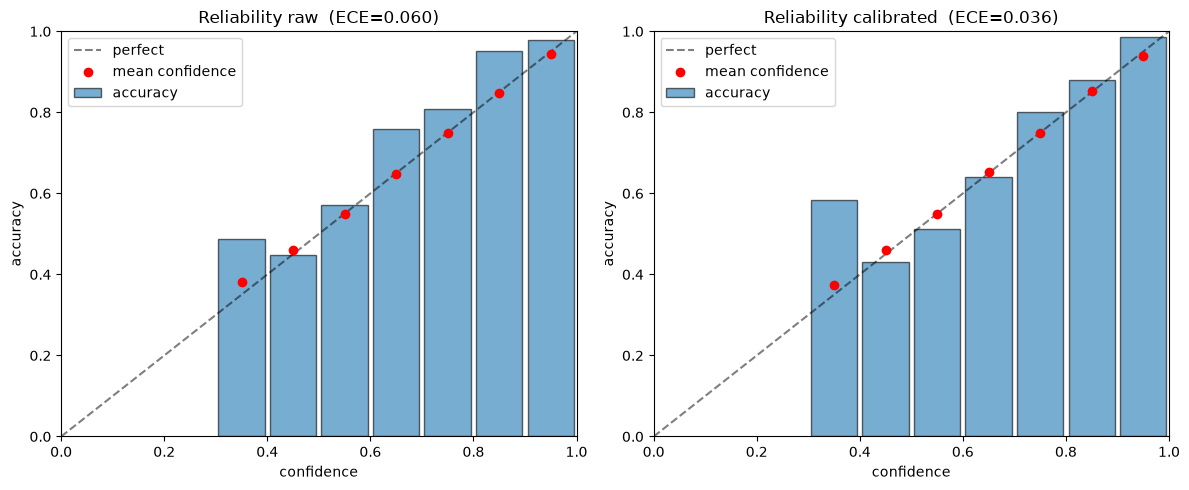


Calibrated validation threshold sweep
    threshold  coverage  accuracy
0        0.40  0.990521  0.773525
1        0.45  0.963665  0.781967
2        0.50  0.902054  0.800350
3        0.55  0.823065  0.836852
4        0.60  0.737757  0.862955
5        0.65  0.657188  0.875000
6        0.70  0.563981  0.893557
7        0.75  0.481833  0.921311
8        0.80  0.410742  0.938462
9        0.85  0.290679  0.983696
10       0.90  0.183254  1.000000
11       0.95  0.060032  1.000000
12       0.99  0.000000       NaN

Calibrated threshold 0.85 (val coverage 29.1%)
Uncalibrated threshold 0.8 for comparison


In [11]:
from sklearn.calibration import CalibratedClassifierCV

# Platt scaling on top of the already-trained Stage 1, fit on val
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

# Platt scaling on top of the already-trained Stage 1, fit on val
cal_clf = CalibratedClassifierCV(FrozenEstimator(simple_clf), method="sigmoid")
cal_clf.fit(X_val, y_val)


# Probabilities on test, raw vs calibrated
raw_pred_test = simple_clf.predict(X_test)
cal_pred_test = cal_clf.predict(X_test)
raw_max_test  = simple_clf.predict_proba(X_test).max(axis=1)
cal_max_test  = cal_clf.predict_proba(X_test).max(axis=1)

# Expected calibration error with 10 equal-width bins
def ece(probs, preds, labels, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    n = len(probs)
    out = 0.0
    for i in range(n_bins):
        m = (probs > bins[i]) & (probs <= bins[i+1])
        if m.sum() == 0:
            continue
        out += (m.sum()/n) * abs((preds[m] == labels[m]).mean() - probs[m].mean())
    return out

ece_raw = ece(raw_max_test, raw_pred_test, y_test)
ece_cal = ece(cal_max_test, cal_pred_test, y_test)
print(f"ECE raw        {ece_raw:.4f}")
print(f"ECE calibrated {ece_cal:.4f}")

# Reliability diagrams, before and after
def reliability(probs, preds, labels, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    centers, accs, confs = [], [], []
    for i in range(n_bins):
        m = (probs > bins[i]) & (probs <= bins[i+1])
        centers.append((bins[i] + bins[i+1]) / 2)
        if m.sum() == 0:
            accs.append(np.nan); confs.append(np.nan)
        else:
            accs.append((preds[m] == labels[m]).mean())
            confs.append(probs[m].mean())
    return np.array(centers), np.array(accs), np.array(confs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name, probs, preds, e in [
    (axes[0], "raw",        raw_max_test, raw_pred_test, ece_raw),
    (axes[1], "calibrated", cal_max_test, cal_pred_test, ece_cal),
]:
    centers, accs, confs = reliability(probs, preds, y_test)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="perfect")
    ax.bar(centers, accs, width=0.09, alpha=0.6, edgecolor="black", label="accuracy")
    ax.scatter(centers, confs, color="red", zorder=5, label="mean confidence")
    ax.set_xlabel("confidence"); ax.set_ylabel("accuracy")
    ax.set_title(f"Reliability {name}  (ECE={e:.3f})")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("reliability_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

# Re-run the threshold sweep on calibrated val probabilities
cal_val_pred  = cal_clf.predict(X_val)
cal_val_proba = cal_clf.predict_proba(X_val).max(axis=1)

rows = []
for t in thresholds:
    m = cal_val_proba >= t
    acc = accuracy_score(y_val[m], cal_val_pred[m]) if m.sum() > 0 else np.nan
    rows.append({"threshold": t, "coverage": m.mean(), "accuracy": acc})
results_cal_df = pd.DataFrame(rows)
print("\nCalibrated validation threshold sweep")
print(results_cal_df)

best_threshold_cal = None
for row in results_cal_df.itertuples():
    if row.accuracy >= TARGET_ACCURACY:
        best_threshold_cal = row.threshold
        best_coverage_cal = row.coverage
        break

print(f"\nCalibrated threshold {best_threshold_cal} (val coverage {best_coverage_cal:.1%})")
print(f"Uncalibrated threshold {best_threshold} for comparison")


In [12]:
# LM-only baseline trained on the same training indices
lm_train = lm_features[idx_train]
lm_test  = lm_features[idx_test]

lm_only_clf = LogisticRegression(max_iter=1000, random_state=42)
lm_only_clf.fit(lm_train, y_train)

# Warm up
_ = lm_only_clf.predict(lm_test)

# Time the inference (median of 5 runs)
times = []
for _ in range(5):
    start = time.perf_counter()
    lm_only_preds = lm_only_clf.predict(lm_test)
    times.append(time.perf_counter() - start)

lm_only_time = float(np.median(times))
lm_only_acc  = accuracy_score(y_test, lm_only_preds)
lm_only_f1   = f1_score(y_test, lm_only_preds, average="macro")

print(f"LM-only accuracy {lm_only_acc:.3f}")
print(f"LM-only macro F1 {lm_only_f1:.3f}")
print(f"Total time {lm_only_time*1000:.2f}ms for {len(y_test)} sentences")
print(f"Per sentence {lm_only_time/len(y_test)*1000:.3f}ms")


LM-only accuracy 0.518
LM-only macro F1 0.518
Total time 0.08ms for 1582 sentences
Per sentence 0.000ms


In [14]:
# Load the fine-tuned BERT
MODEL_DIR = "finbert-finetuned-sentfin"
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
bert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
bert_model.eval()

# Grab only the test sentences stage 1 was uncertain about
uncertain_mask = ~first_pass
uncertain_sentences = [s for s, u in zip(sent_test, uncertain_mask) if u]

print(f"Running BERT on {len(uncertain_sentences)} of {len(sent_test)} sentences ({uncertain_mask.mean():.1%})")

# Run BERT only on those
with torch.no_grad():
    inputs = tokenizer(
        uncertain_sentences,
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )
    logits = bert_model(**inputs).logits
    bert_preds = logits.argmax(dim=-1).numpy()

# Map ints back to label strings
id2label = {0: "negative", 1: "neutral", 2: "positive"}
bert_preds_str = np.array([id2label[i] for i in bert_preds])


# Combine stage 1 confident predictions with BERT for uncertain ones
final_preds = y_pred.copy()
final_preds[uncertain_mask] = bert_preds_str

cascade_accuracy = accuracy_score(y_test, final_preds)
stage2_accuracy = accuracy_score(y_test[uncertain_mask], bert_preds_str) if uncertain_mask.sum() > 0 else float("nan")

print(f"\nCascade results")
print(f"Stage 1 handled {first_pass.sum()} ({first_pass.mean():.1%}) at {classified_accuracy:.3f} accuracy")
print(f"Stage 2 handled {uncertain_mask.sum()} ({uncertain_mask.mean():.1%}) at {stage2_accuracy:.3f} accuracy")
print(f"Final cascade accuracy {cascade_accuracy:.3f}")

print("\nFull cascade classification")
print(classification_report(y_test, final_preds))


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 9444.20it/s]


Running BERT on 1048 of 1582 sentences (66.2%)

Cascade results
Stage 1 handled 534 (33.8%) at 0.964 accuracy
Stage 2 handled 1048 (66.2%) at 0.822 accuracy
Final cascade accuracy 0.870

Full cascade classification
              precision    recall  f1-score   support

    negative       0.89      0.86      0.88       475
     neutral       0.85      0.85      0.85       539
    positive       0.87      0.89      0.88       568

    accuracy                           0.87      1582
   macro avg       0.87      0.87      0.87      1582
weighted avg       0.87      0.87      0.87      1582



In [15]:
# Calibrated cascade: same routing logic, but using cal_clf's confidence
y_pred_cal       = cal_clf.predict(X_test)
max_proba_cal    = cal_clf.predict_proba(X_test).max(axis=1)
first_pass_cal   = max_proba_cal >= best_threshold_cal
uncertain_cal    = ~first_pass_cal
uncertain_sents_cal = [s for s, u in zip(sent_test, uncertain_cal) if u]

print(f"Calibrated cascade: BERT on {len(uncertain_sents_cal)} of {len(sent_test)} ({uncertain_cal.mean():.1%})")

with torch.no_grad():
    inputs = tokenizer(uncertain_sents_cal, padding=True, truncation=True,
                       max_length=256, return_tensors="pt")
    bert_int_cal = bert_model(**inputs).logits.argmax(dim=-1).numpy()
bert_str_cal = np.array([id2label[i] for i in bert_int_cal])

final_preds_cal = y_pred_cal.copy()
final_preds_cal[uncertain_cal] = bert_str_cal

cascade_acc_cal = accuracy_score(y_test, final_preds_cal)
cascade_f1_cal  = f1_score(y_test, final_preds_cal, average="macro")
classified_accuracy_cal = accuracy_score(y_test[first_pass_cal], y_pred_cal[first_pass_cal]) if first_pass_cal.sum() > 0 else 0
stage2_accuracy_cal = accuracy_score(y_test[uncertain_cal], bert_str_cal) if uncertain_cal.sum() > 0 else float("nan")

print(f"\nCalibrated cascade results")
print(f"Stage 1 handled {first_pass_cal.sum()} ({first_pass_cal.mean():.1%}) at {classified_accuracy_cal:.3f} accuracy")
print(f"Stage 2 handled {uncertain_cal.sum()} ({uncertain_cal.mean():.1%}) at {stage2_accuracy_cal:.3f} accuracy")
print(f"Final calibrated cascade accuracy {cascade_acc_cal:.3f}, macro F1 {cascade_f1_cal:.3f}")
print("\nClassification report")
print(classification_report(y_test, final_preds_cal))


Calibrated cascade: BERT on 1100 of 1582 (69.5%)

Calibrated cascade results
Stage 1 handled 482 (30.5%) at 0.959 accuracy
Stage 2 handled 1100 (69.5%) at 0.829 accuracy
Final calibrated cascade accuracy 0.869, macro F1 0.868

Classification report
              precision    recall  f1-score   support

    negative       0.89      0.86      0.87       475
     neutral       0.85      0.85      0.85       539
    positive       0.87      0.89      0.88       568

    accuracy                           0.87      1582
   macro avg       0.87      0.87      0.87      1582
weighted avg       0.87      0.87      0.87      1582



In [16]:
n_test = len(y_test)

# Full stage 1 (LM + TF-IDF), no abstention
_ = simple_clf.predict(X_test)
times = []
for _ in range(5):
    start = time.perf_counter()
    stage1_preds = simple_clf.predict(X_test)
    times.append(time.perf_counter() - start)
stage1_time = float(np.median(times))
stage1_acc  = accuracy_score(y_test, stage1_preds)
stage1_f1   = f1_score(y_test, stage1_preds, average="macro")


# BERT alone on every sentence
with torch.no_grad():
    _ = bert_model(**tokenizer(sent_test[:5], padding=True, truncation=True,
                               max_length=256, return_tensors="pt"))

times = []
for _ in range(5):
    start = time.perf_counter()
    with torch.no_grad():
        inputs = tokenizer(sent_test, padding=True, truncation=True,
                           max_length=256, return_tensors="pt")
        logits_all = bert_model(**inputs).logits
        bert_all_int = logits_all.argmax(dim=-1).numpy()
    times.append(time.perf_counter() - start)

bert_only_time  = float(np.median(times))
bert_only_preds = np.array([id2label[i] for i in bert_all_int])
bert_only_acc   = accuracy_score(y_test, bert_only_preds)
bert_only_f1    = f1_score(y_test, bert_only_preds, average="macro")


# Cascade end-to-end (raw confidence)
times = []
for _ in range(5):
    start = time.perf_counter()
    s1 = simple_clf.predict(X_test)
    s1_conf = simple_clf.predict_proba(X_test).max(axis=1)
    uncertain = s1_conf < best_threshold
    uncertain_sents = [s for s, u in zip(sent_test, uncertain) if u]
    if len(uncertain_sents) > 0:
        with torch.no_grad():
            inputs = tokenizer(uncertain_sents, padding=True, truncation=True,
                               max_length=256, return_tensors="pt")
            s2_int = bert_model(**inputs).logits.argmax(dim=-1).numpy()
            s2 = np.array([id2label[i] for i in s2_int])
        casc = s1.copy()
        casc[uncertain] = s2
    else:
        casc = s1
    times.append(time.perf_counter() - start)

cascade_time  = float(np.median(times))
cascade_preds = casc
cascade_acc   = accuracy_score(y_test, cascade_preds)
cascade_f1    = f1_score(y_test, cascade_preds, average="macro")
cascade_calls = int(uncertain.sum())


# Calibrated cascade end-to-end
times = []
for _ in range(5):
    start = time.perf_counter()
    s1c = cal_clf.predict(X_test)
    s1c_conf = cal_clf.predict_proba(X_test).max(axis=1)
    unc_c = s1c_conf < best_threshold_cal
    unc_sents_c = [s for s, u in zip(sent_test, unc_c) if u]
    if len(unc_sents_c) > 0:
        with torch.no_grad():
            inputs = tokenizer(unc_sents_c, padding=True, truncation=True,
                               max_length=256, return_tensors="pt")
            s2c_int = bert_model(**inputs).logits.argmax(dim=-1).numpy()
            s2c = np.array([id2label[i] for i in s2c_int])
        casc_c = s1c.copy()
        casc_c[unc_c] = s2c
    else:
        casc_c = s1c
    times.append(time.perf_counter() - start)

cascade_cal_time  = float(np.median(times))
cascade_cal_calls = int(unc_c.sum())


# Summary table
summary = pd.DataFrame([
    {"system": "LM-only LR",    "accuracy": lm_only_acc,    "macro_f1": lm_only_f1,
     "total_time_s": lm_only_time,    "ms_per_sentence": lm_only_time/n_test*1000,    "bert_calls": 0},
    {"system": "Full Stage 1",  "accuracy": stage1_acc,     "macro_f1": stage1_f1,
     "total_time_s": stage1_time,     "ms_per_sentence": stage1_time/n_test*1000,     "bert_calls": 0},
    {"system": "BERT alone",    "accuracy": bert_only_acc,  "macro_f1": bert_only_f1,
     "total_time_s": bert_only_time,  "ms_per_sentence": bert_only_time/n_test*1000,  "bert_calls": n_test},
    {"system": "Cascade",       "accuracy": cascade_acc,    "macro_f1": cascade_f1,
     "total_time_s": cascade_time,    "ms_per_sentence": cascade_time/n_test*1000,    "bert_calls": cascade_calls},
    {"system": "Cascade (cal)", "accuracy": cascade_acc_cal, "macro_f1": cascade_f1_cal,
     "total_time_s": cascade_cal_time, "ms_per_sentence": cascade_cal_time/n_test*1000, "bert_calls": cascade_cal_calls},
])

print("\nBenchmark summary")
print(summary.round(4).to_string(index=False))



Benchmark summary
       system  accuracy  macro_f1  total_time_s  ms_per_sentence  bert_calls
   LM-only LR    0.5183    0.5177        0.0001           0.0001           0
 Full Stage 1    0.7566    0.7559        0.0004           0.0002           0
   BERT alone    0.8698    0.8699        5.6889           3.5960        1582
      Cascade    0.8698    0.8699        3.1622           1.9989        1048
Cascade (cal)    0.8685    0.8684        3.3177           2.0971        1100



LM-only LR
              precision    recall  f1-score   support

    negative       0.62      0.44      0.51       475
     neutral       0.47      0.60      0.53       539
    positive       0.52      0.51      0.51       568

    accuracy                           0.52      1582
   macro avg       0.54      0.52      0.52      1582
weighted avg       0.53      0.52      0.52      1582


Full Stage 1
              precision    recall  f1-score   support

    negative       0.80      0.71      0.75       475
     neutral       0.74      0.75      0.74       539
    positive       0.74      0.80      0.77       568

    accuracy                           0.76      1582
   macro avg       0.76      0.75      0.76      1582
weighted avg       0.76      0.76      0.76      1582


BERT alone
              precision    recall  f1-score   support

    negative       0.89      0.87      0.88       475
     neutral       0.85      0.84      0.85       539
    positive       0.87      0.90    

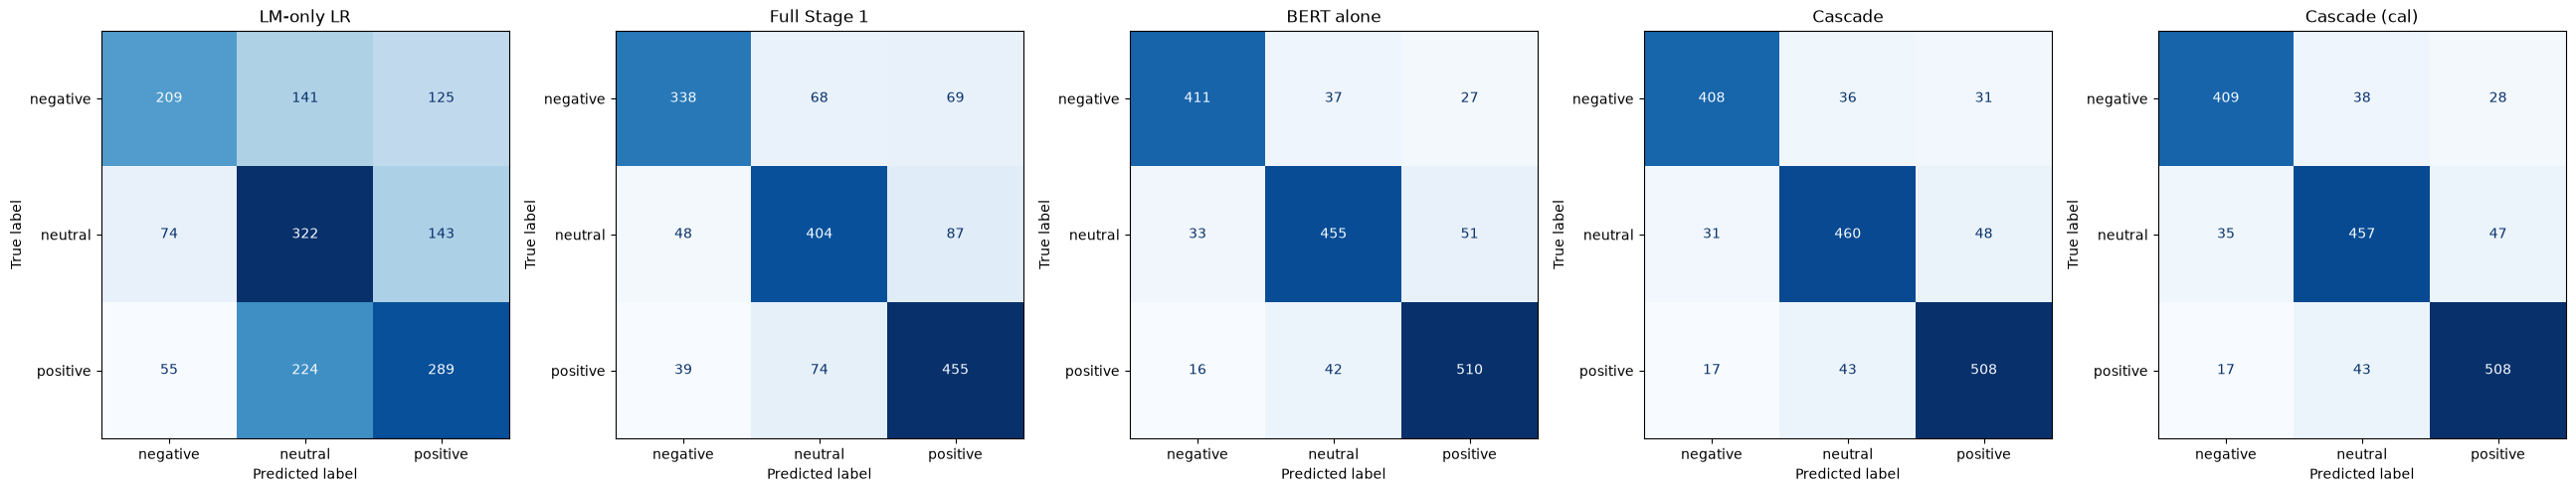

In [17]:
systems = [
    ("LM-only LR",    lm_only_preds),
    ("Full Stage 1",  stage1_preds),
    ("BERT alone",    bert_only_preds),
    ("Cascade",       cascade_preds),
    ("Cascade (cal)", final_preds_cal),
]

# Print per-class reports
for name, preds in systems:
    print(f"\n{name}")
    print(classification_report(y_test, preds))


# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 5, figsize=(26, 5))
labels = ["negative", "neutral", "positive"]

for ax, (name, preds) in zip(axes, systems):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, labels=labels, ax=ax,
        cmap="Blues", colorbar=False
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()


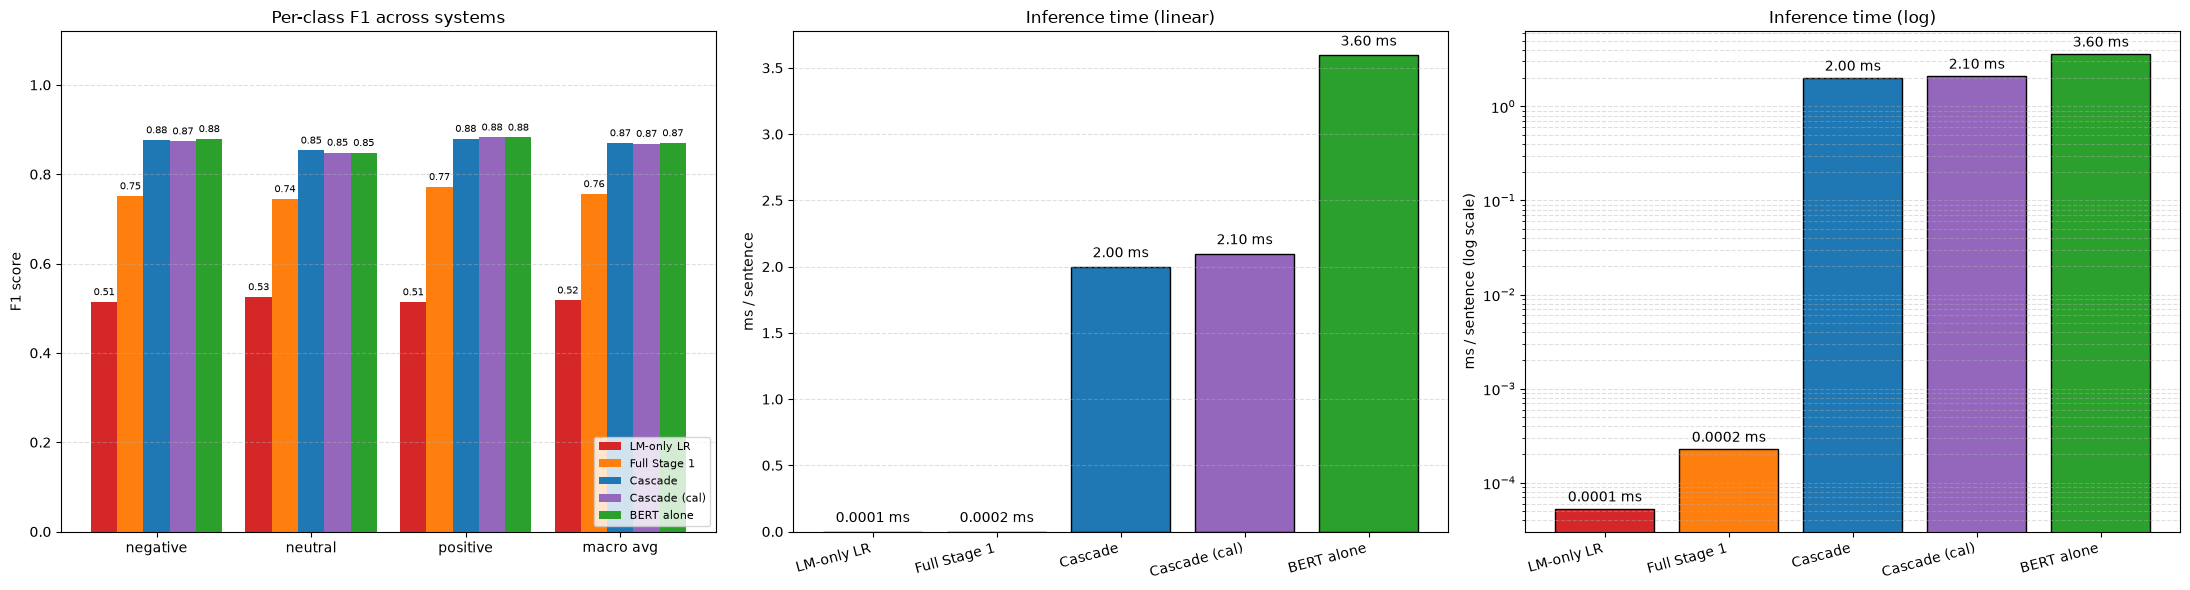


Wall clock times
LM-only LR      0.0001 ms/sentence
Full Stage 1    0.0002 ms/sentence
Cascade         1.9989 ms/sentence
Cascade (cal)   2.0971 ms/sentence
BERT alone      3.5960 ms/sentence


In [18]:

system_order = ["LM-only LR", "Full Stage 1", "Cascade", "Cascade (cal)", "BERT alone"]
colors_dict = {"LM-only LR": "#d62728", "Full Stage 1": "#ff7f0e",
               "Cascade": "#1f77b4", "Cascade (cal)": "#9467bd", "BERT alone": "#2ca02c"}
ordered_colors = [colors_dict[s] for s in system_order]

times_per_sent = summary.set_index("system")["ms_per_sentence"].to_dict()
times_data = [times_per_sent[s] for s in system_order]

# Per-class F1
labels = ["negative", "neutral", "positive"]
systems_for_f1 = [
    ("LM-only LR",    lm_only_preds),
    ("Full Stage 1",  stage1_preds),
    ("Cascade",       cascade_preds),
    ("Cascade (cal)", final_preds_cal),
    ("BERT alone",    bert_only_preds),
]
f1_colors = ["#d62728", "#ff7f0e", "#1f77b4", "#9467bd", "#2ca02c"]

per_class_f1 = {}
for name, preds in systems_for_f1:
    report = classification_report(y_test, preds, output_dict=True)
    per_class_f1[name] = [report[c]["f1-score"] for c in labels] + [report["macro avg"]["f1-score"]]


fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Per-class F1
ax = axes[0]
x = np.arange(len(labels) + 1)
width = 0.17
for i, (name, f1s) in enumerate(per_class_f1.items()):
    bars = ax.bar(x + i*width, f1s, width, label=name, color=f1_colors[i])
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f"{h:.2f}", ha="center", va="bottom", fontsize=7)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(labels + ["macro avg"])
ax.set_ylabel("F1 score")
ax.set_title("Per-class F1 across systems")
ax.legend(loc="lower right", fontsize=8)
ax.set_ylim(0, 1.12)
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Wall clock time, linear scale
ax = axes[1]
bars = ax.bar(system_order, times_data, color=ordered_colors, edgecolor="black")
for bar, val in zip(bars, times_data):
    label = f"{val:.4f} ms" if val < 0.1 else f"{val:.2f} ms"
    ax.text(bar.get_x() + bar.get_width()/2, val + max(times_data)*0.02,
            label, ha="center", fontsize=10)
ax.set_ylabel("ms / sentence")
ax.set_title("Inference time (linear)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

# Wall clock time, log scale
ax = axes[2]
bars = ax.bar(system_order, times_data, color=ordered_colors, edgecolor="black")
for bar, val in zip(bars, times_data):
    label = f"{val:.4f} ms" if val < 0.1 else f"{val:.2f} ms"
    ax.text(bar.get_x() + bar.get_width()/2, val * 1.2,
            label, ha="center", fontsize=10)
ax.set_yscale("log")
ax.set_ylabel("ms / sentence (log scale)")
ax.set_title("Inference time (log)")
ax.grid(axis="y", linestyle="--", alpha=0.4, which="both")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

plt.tight_layout()
plt.savefig("benchmark_f1_time.png", dpi=150, bbox_inches="tight")
plt.show()


print("\nWall clock times")
for s, t in zip(system_order, times_data):
    print(f"{s:<15} {t:.4f} ms/sentence")


In [19]:
# Build feature name vector matching X_train's column order
lm_feature_names    = ["lm_positive", "lm_negative", "lm_polarity",
                       "lm_subjectivity", "n_words", "n_numbers"]
tfidf_feature_names = tfidf.get_feature_names_out().tolist()
feature_names = np.array(lm_feature_names + tfidf_feature_names)

# Top features per class from the LR coefficients
coefs = simple_clf.coef_
classes = simple_clf.classes_

print("Top 15 features per class by |coef|")
for cls, row in zip(classes, coefs):
    print(f"\n{cls}")
    idx = np.argsort(np.abs(row))[::-1][:15]
    for i in idx:
        print(f"  {feature_names[i]:<20} {row[i]:+.3f}")


Top 15 features per class by |coef|

negative
  slips                +3.847
  falls                +3.836
  sell                 +3.498
  fall                 +3.338
  dips                 +2.902
  bearish              +2.672
  lower                +2.649
  low                  +2.547
  plunges              +2.497
  booking              +2.005
  plunge               +1.955
  slide                +1.935
  tanks                +1.934
  pressure             +1.925
  cautious             +1.886

neutral
  sebi                 +2.666
  appoints             +2.368
  sell                 -2.283
  surges               -2.076
  flat                 +2.043
  cent                 -2.038
  ipo                  +2.000
  bullish              -1.883
  steady               +1.871
  mixed                +1.858
  falls                -1.840
  rises                -1.838
  futures              -1.819
  raises               -1.803
  hits                 -1.789

positive
  surges               +3.805
  ris

SHAP computed on 1048 escalated sentences

Top 20 features driving the predicted class on escalated sentences
  n_numbers            mean|SHAP|=0.1520
  lm_polarity          mean|SHAP|=0.1343
  lm_negative          mean|SHAP|=0.1146
  lm_positive          mean|SHAP|=0.0835
  lm_subjectivity      mean|SHAP|=0.0572
  profit               mean|SHAP|=0.0525
  net                  mean|SHAP|=0.0375
  high                 mean|SHAP|=0.0361
  ipo                  mean|SHAP|=0.0312
  sell                 mean|SHAP|=0.0310
  sebi                 mean|SHAP|=0.0304
  shares               mean|SHAP|=0.0294
  crore                mean|SHAP|=0.0271
  fall                 mean|SHAP|=0.0269
  cent                 mean|SHAP|=0.0258
  stock                mean|SHAP|=0.0240
  falls                mean|SHAP|=0.0237
  futures              mean|SHAP|=0.0232
  rises                mean|SHAP|=0.0225
  slips                mean|SHAP|=0.0211


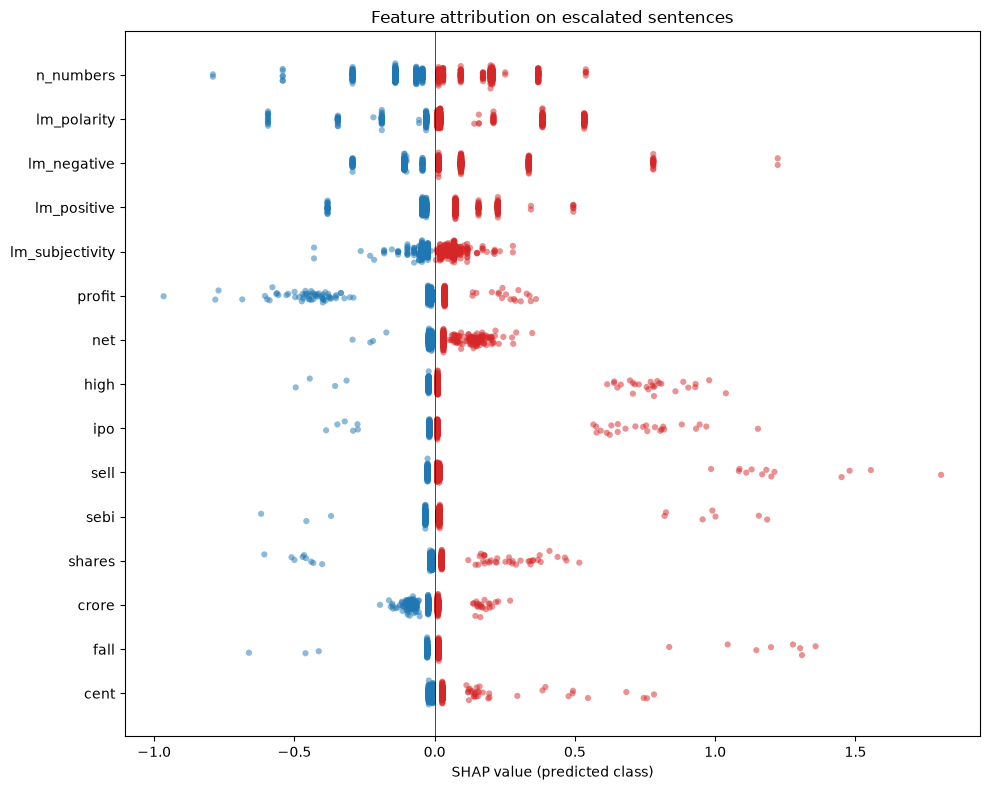

In [20]:
# Exact SHAP for linear classifiers: phi_jk = coef[k, j] * (x_j - bg_mean_j)

X_train_dense = X_train.toarray()
bg_mean = X_train_dense.mean(axis=0)

escalated_rows = X_test[uncertain_mask].toarray()
escalated_pred = y_pred[uncertain_mask]
class_to_idx = {c: i for i, c in enumerate(classes)}
pred_idx = np.array([class_to_idx[p] for p in escalated_pred])

# Per-sentence SHAP for its predicted class
sv_pred = (escalated_rows - bg_mean) * coefs[pred_idx]
print(f"SHAP computed on {sv_pred.shape[0]} escalated sentences")

# Top features by mean(|SHAP|) on the escalated set
mean_abs = np.abs(sv_pred).mean(axis=0)
top_idx = np.argsort(mean_abs)[::-1][:20]
print("\nTop 20 features driving the predicted class on escalated sentences")
for i in top_idx:
    print(f"  {feature_names[i]:<20} mean|SHAP|={mean_abs[i]:.4f}")

# Strip plot, one row per top feature, one dot per escalated sentence
K = 15
top = np.argsort(mean_abs)[::-1][:K]

fig, ax = plt.subplots(figsize=(10, 8))
rng = np.random.RandomState(42)
for row, j in enumerate(top):
    vals = sv_pred[:, j]
    jitter = rng.normal(0, 0.08, size=len(vals))
    colors = ["#1f77b4" if v < 0 else "#d62728" for v in vals]
    ax.scatter(vals, row + jitter, c=colors, alpha=0.5, s=20, edgecolor="none")

ax.set_yticks(range(K))
ax.set_yticklabels([feature_names[j] for j in top])
ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("SHAP value (predicted class)")
ax.set_title("Feature attribution on escalated sentences")
plt.tight_layout()
plt.savefig("shap_escalated.png", dpi=150, bbox_inches="tight")
plt.show()


In [21]:
import os
bert_size_mb = sum(os.path.getsize(os.path.join(MODEL_DIR, f))
                   for f in os.listdir(MODEL_DIR)
                   if os.path.isfile(os.path.join(MODEL_DIR, f))) / 1e6
bert_params  = sum(p.numel() for p in bert_model.parameters())
lr_params    = simple_clf.coef_.size + simple_clf.intercept_.size

print(f"BERT size on disk  {bert_size_mb:>8.1f} MB")
print(f"BERT parameters    {bert_params:>10,}")
print(f"LR parameters      {lr_params:>10,}")


BERT size on disk     439.9 MB
BERT parameters    109,754,115
LR parameters           3,021


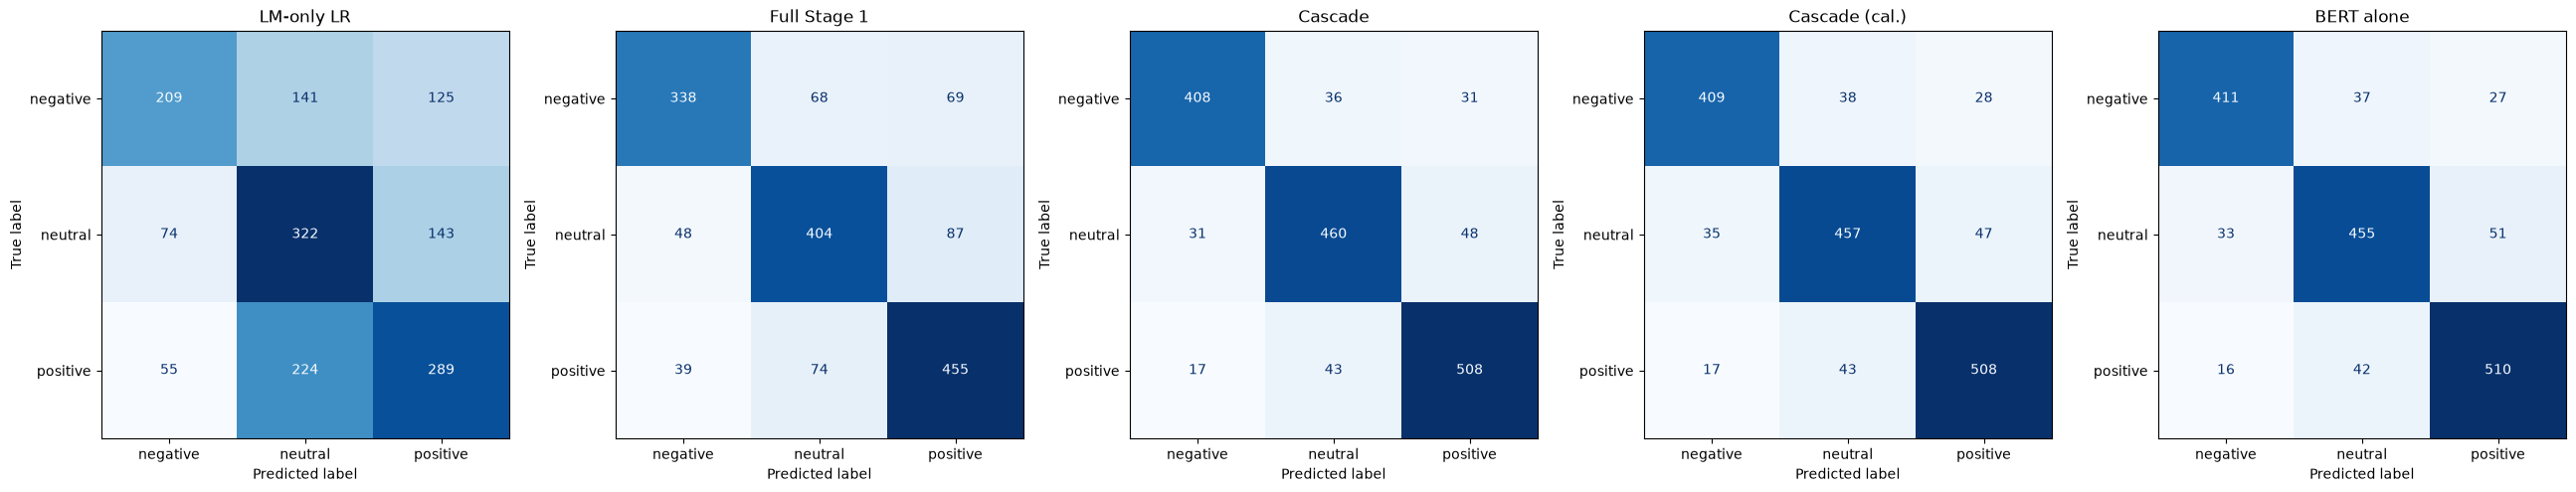

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Each *_preds array must be predictions on y_test for the fine-tuned-Stage-2 condition:
# lm_only_preds, stage1_preds, cascade_preds, final_preds_cal, bert_only_preds

systems = [
    ("LM-only LR",    lm_only_preds),
    ("Full Stage 1",  stage1_preds),
    ("Cascade",       cascade_preds),
    ("Cascade (cal.)", final_preds_cal),
    ("BERT alone",    bert_only_preds),
]

labels = ["negative", "neutral", "positive"]

fig, axes = plt.subplots(1, 5, figsize=(26, 5))

for ax, (name, preds) in zip(axes, systems):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, labels=labels, ax=ax,
        cmap="Blues", colorbar=False
    )
    ax.set_title(name)

plt.tight_layout()
plt.savefig("confusion_matrices_s.png", dpi=150, bbox_inches="tight")
plt.show()